<a href="https://colab.research.google.com/github/maureen-zhang/qiskit-subset-sum/blob/main/SUBSET_SUM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Subset Sum Solver 


This following notebook solves the subset sum problem using the vanilla Grover search algorithm. 

For a more efficient impmlementation, see:

Benoit-Schwartz-Cytron, 'Optimization of a Quantum Subset Sum Oracle'
https://arxiv.org/pdf/2410.01775







## Subset-Sum Problem

**Input:** A finite list of positive integers $M = \{m_0, m_1, \dots, m_{n-1}\}$ and a target integer $t$.

**Output:** A subset $I \subseteq \{0, 1, \dots, n-1\}$ such that $\sum_{i \in I} m_i = t$. We represent the subset $I$ by a binary string of length $n$,

$$
I = (I_0, I_1, \dots, I_{n-1}),
$$

where $I_j = 1$ if $m_j$ is included in the subset and $I_j = 0$ otherwise.

## Solution Using Grover's Search Algorithm

We solve the subset-sum problem using Grover's quantum search algorithm.

To do so, we construct several reusable quantum subroutines:

- **Adder Gate:** Given a finite list $M = \{m_0, m_1, \dots, m_{n-1}\}$, the adder gate takes an $n$-qubit state $|x\rangle$ and computes the sum

$$
\sum_{i=0}^{n-1} m_i x_i
$$

in binary, storing it in a collection of ancilla qubits whose size is determined by the binary representation of the worst-case sum $\sum_{i = 0}^{n-1} m_i$.

- **Phase Circuit:** Given a integers $t$ and $d$, this gate takes a $d$ qubit input $\lvert y \rangle$ , representing the target sum $t$ in a binary string of length $d$, and marks the state with a phase $-1$ precisely when $\lvert y \rangle =| t \rangle$. 

- **Marker Oracle:** The marker oracle takes the list $M$, the target sum $t$, and an input state $\lvert x\rangle$. If the subset encoded by $\lvert x \rangle$ sums to $t$, the oracle applies a phase flip:
$$
\lvert x\rangle \mapsto -\lvert x\rangle.
$$ 
Otherwise, it leaves the state unchanged: 
$$
\lvert x\rangle \mapsto \lvert x\rangle.
$$

- **Diffusion Oracle:** The diffusion oracle reflects quantum states about the uniform superposition state $|s\rangle$. It is defined by
$$
|s\rangle \mapsto -|s\rangle,
$$
$$
|s^\perp\rangle \mapsto  |s^\perp\rangle,
$$
where $|s^\perp\rangle$ denotes any state orthogonal to $|s\rangle$ in the span of $\{\lvert s \rangle, \langle t \rangle\}$. 


## Space Complexity

The total number of qubits required is

$$
n + 2d - 1,
$$

where

$$
d = \left\lceil \log_2\!\left(\sum_{i=0}^{n-1} m_i + 1\right) \right\rceil.
$$

Therefore, the space complexity is

$$
n + 2\left\lceil \log_2\!\left(\sum_{i=0}^{n-1} m_i + 1\right) \right\rceil - 1.
$$

This consists of:

- $n$ qubits for the input register encoding the subset.
- $d$ qubits for the sum register.
- $d-1$ qubits for the carry register used by the adder circuit.

Special thanks to Akos for making his adder circuit available to the open-source quantum computing community.

**Adder Circuit:**
[Github repo](https://github.com/akos-nagy/quantum_shifter)

# Solver Implementation

## Input
The following code specify the input for all the subset sum problem and the quantum gates in this notebook. 

In [1]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import ZGate
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# M = given list of positive integers
M = np.array([1,3,4,7])

# target_sum = the target sum we want to achieve by summing a subset of the integers in M
target_sum = 11

## Initializing Global Variables

The following block initializes the quantum registers: the input register $|x\rangle$, which stores the subset information; the ancilla register $|y\rangle$, which stores information for possible subset sums; and the carry register, which is used for computation.

In [3]:
# n = number of positive integers provided
n = len(M)

# We need to determine the number of bits needed to represent the maximum possible sum of subsets of M
max_sum = sum(M)
bits_needed = int(max_sum).bit_length()

We now initialize the quantum, ancilla, and carry registers.

In [4]:
quantum_register = QuantumRegister(size=n, name='x')
ancilla_register = AncillaRegister(size=bits_needed, name='y')
carry_register = AncillaRegister(size=bits_needed-1, name='carry')

## State Preparation

This gate applies a Hadamard transformation to every qubit in the input register $|x\rangle$, creating an equal superposition over all possible basis states.

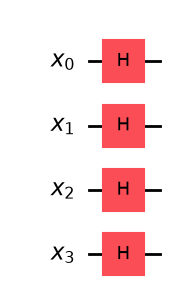

In [5]:
state_preparation_circuit = QuantumCircuit(quantum_register, name="state preparation")
state_preparation_circuit.h(quantum_register)
state_preparation_circuit.draw(output="mpl")

In [6]:
Prep = state_preparation_circuit.to_gate(label="Prep")

## Marker Circuit

Given a target quantum state $|t\rangle$, the marker circuit takes an input state $|x\rangle$ and applies a phase flip if and only if $x=t$. That is,

$$
|x\rangle \mapsto
\begin{cases}
-|x\rangle, & \text{if } x=t, \\
\;\;|x\rangle, & \text{otherwise}.
\end{cases}
$$

We implement the $\text{Marker circuit}$ as the composition of $\text{Adder}$ gate, $\text{Phase}$ gate and $\text{Subtractor}$ gate:

$$
\text{Marker}
=
\text{Subtractor}
\circ
\text{Phase}
\circ
\text{Adder}.
$$


### Adder gate (credit Akos)

The first step in converting the subset sum problem into a Grover search problem is to encode it as a function $F$. Recall that the subset sum problem, we are given a list of positive integers $ M = \{m_0, m_1, \dots, m_{n-1}\}$.

Let $F: \mathbb{F}_2^n \rightarrow \mathbb{Z}$ be defined as

\begin{equation}
    F(x_0, x_1 , \dots, x_n) = m_0 x_0 + m_1 x_1 \dots + m_{n-1} x_{n-1}.
\end{equation}
Our goal is the solve the equation
\begin{equation}
    F(x_0, x_1, \dots x_{n-1}) = t,
\end{equation}

using Grover's algorithm.

One can thingk of $F$ as a function that represents the sum of the elements in the subset of $M$ indicated by the bitstring $(x_0, x_1, \dots, x_{n-1})$. For example, if the first qubit in the input register is $1$, we include $m_0$ in the sum; otherwise, we omit $m_0$ from the summation. The same rule applies to each element $m_i$ in the list.


We define the $\text{Adder}$ oracle as:

$$
\mathrm{Adder}(|x\rangle) = F(x).
$$

More precisely, the adder gate $\mathrm{Adder}$ computes the function $F$ while preserving the input register and uncomputing the carry register:

$$
\mathrm{Adder}\bigl(|x\rangle |\mathrm{ancilla}\rangle |\mathrm{carry}\rangle\bigr)
=
|x\rangle |F(x)\rangle |\mathrm{carry}\rangle.
$$

In [7]:
# This block of code implements a controlled measurement-free quantum shifter
# Copied from github.com/akos-nagy/quantum_shifter
def controlled_measurement_free_quantum_shifter(k, d):
    if not (isinstance(k, int) and isinstance(d, int) and d > 0):
        raise TypeError(f"k and d have to be integers and d has to be positive")
        return 0

    k %= 1 << d

    qcontrol = QuantumRegister(1, "control")
    qregx = QuantumRegister(d, "x")
    quantum_shifter_circuit = QuantumCircuit(qcontrol, qregx, name=f"{d}-bit controlled {k}-shifter")

    if d == 1 and k == 1:
        quantum_shifter_circuit.cx(qcontrol[0], qregx[0])
        return quantum_shifter_circuit

    qcarry = AncillaRegister(d - 1, "carry")
    quantum_shifter_circuit.add_register(qcarry)

    if k == 0:
        return quantum_shifter_circuit

    least_significant_bit = (-k&k).bit_length() - 1 # at least 0

    if least_significant_bit > 0:
        quantum_shifter_circuit.compose(controlled_measurement_free_quantum_shifter(k >> least_significant_bit, d - least_significant_bit), qubits=qcontrol[:] + qregx[least_significant_bit:] + qcarry[least_significant_bit:], inplace=True)
        return quantum_shifter_circuit

    compute_carry_gate = compute_carry().to_gate()
    uncompute_carry_gate = compute_carry_gate.inverse()
    uncompute_carry_gate.label = f"uncompute carry"

    if d == 2:
        if k == 1:
            quantum_shifter_circuit.compose(compute_carry_gate, qubits=[qcontrol[0], qregx[0], qcarry[0]], inplace=True)
            quantum_shifter_circuit.cx(qcarry[0], qregx[1])
            quantum_shifter_circuit.compose(uncompute_carry_gate, qubits=[qcontrol[0], qregx[0], qcarry[0]], inplace=True)
            quantum_shifter_circuit.cx(qcontrol[0], qregx[0])
        if k == 3:
            quantum_shifter_circuit.cx(qcontrol[0], qregx[0])
            quantum_shifter_circuit.compose(compute_carry_gate, qubits=[qcontrol[0], qregx[0], qcarry[0]], inplace=True)
            quantum_shifter_circuit.cx(qcarry[0], qregx[1])
            quantum_shifter_circuit.compose(uncompute_carry_gate, qubits=[qcontrol[0], qregx[0], qcarry[0]], inplace=True)
        return quantum_shifter_circuit

    # k is now odd

    k_bits = (k >> np.arange(d))%2

    if k_bits[0] == 1:
        quantum_shifter_circuit.cx(qcontrol[0], qregx[0])   
    quantum_shifter_circuit.compose(compute_carry_gate, qubits=[qcontrol[0], qregx[0], qcarry[0]], inplace=True)
    
    for idx in range(d - 2):
        if k_bits[idx] != k_bits[idx + 1]:
            quantum_shifter_circuit.cx(qcontrol[0], qcarry[idx])
        if k_bits[idx + 1] == 1:
            quantum_shifter_circuit.cx(qcarry[idx], qregx[idx + 1])
        quantum_shifter_circuit.compose(compute_carry_gate, qubits=[qcarry[idx], qregx[idx + 1], qcarry[idx + 1]], inplace=True)

    if k_bits[- 2] != k_bits[- 1]:
        quantum_shifter_circuit.cx(qcontrol[0], qregx[- 1])
    quantum_shifter_circuit.cx(qcarry[- 1], qregx[- 1])

    for idx in range(d - 3, - 1, - 1):
        quantum_shifter_circuit.compose(uncompute_carry_gate, qubits=[qcarry[idx], qregx[idx + 1], qcarry[idx + 1]], inplace=True)
        if k_bits[idx + 1] == 0:
            quantum_shifter_circuit.cx(qcarry[idx], qregx[idx + 1])
        if k_bits[idx] != k_bits[idx + 1]:
            quantum_shifter_circuit.cx(qcontrol[0], qcarry[idx])

    quantum_shifter_circuit.compose(uncompute_carry_gate, qubits=[qcontrol[0], qregx[0], qcarry[0]], inplace=True)

    if k_bits[0] == 0:
        quantum_shifter_circuit.cx(qregx[0], qregx[1])
        quantum_shifter_circuit.x(qregx[0])

    return quantum_shifter_circuit


def compute_carry():
    qcontrol, qtarget = QuantumRegister(2, "control"), AncillaRegister(1, "target")

    compute_carry_gate = QuantumCircuit(qcontrol, qtarget, name=f"compute carry")

    compute_carry_gate.h(qtarget[0])
    compute_carry_gate.t(qtarget[0])

    compute_carry_gate.cx(qcontrol[0], qtarget[0])
    compute_carry_gate.cx(qcontrol[1], qtarget[0])
    compute_carry_gate.cx(qtarget[0], qcontrol[1])
    compute_carry_gate.cx(qtarget[0], qcontrol[0])

    compute_carry_gate.tdg(qcontrol)
    compute_carry_gate.t(qtarget[0])

    compute_carry_gate.cx(qtarget[0], qcontrol[0])
    compute_carry_gate.cx(qtarget[0], qcontrol[1])

    compute_carry_gate.h(qtarget[0])

    return compute_carry_gate

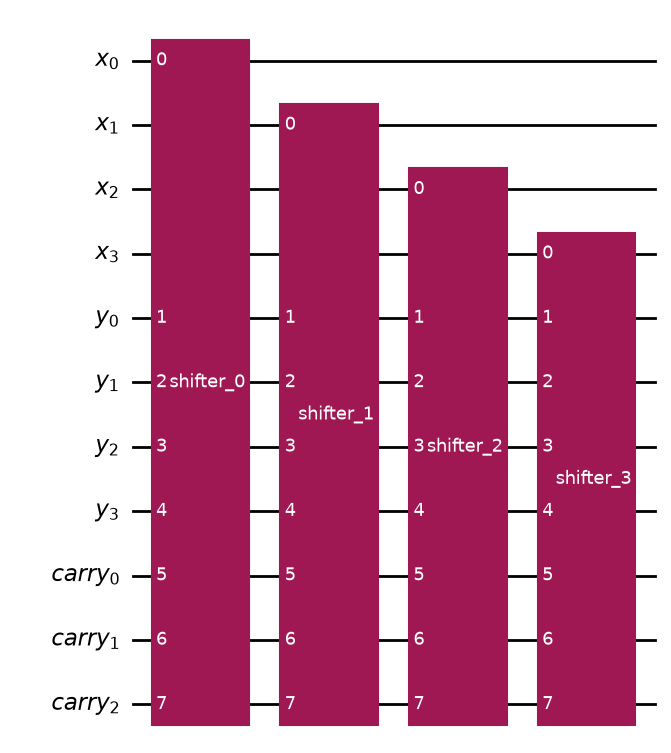

In [8]:
# Iterate though the list of integers and apply the controlled measurement-free quantum shifter for each integer
adder_circuit = QuantumCircuit(quantum_register, ancilla_register, carry_register, name="adder circuit")

for i in range(n):
    adder_circuit.compose(controlled_measurement_free_quantum_shifter(int(M[i]), int(bits_needed)).to_gate(label=f"shifter_{i}"), qubits=[quantum_register[i]] + ancilla_register[:] + carry_register[:], inplace=True)

Adder = adder_circuit.to_gate(label="adder")
adder_circuit.draw(output="mpl")

In [9]:
# The inverse of the adder circuit is the subtractor circuit.
Subtractor = Adder.inverse()

### Phase Circuit

The phase gate acts on the ancilla register. It takes as input a number $y$ and performs the transformation

$$
|y\rangle \mapsto
\begin{cases}
|y\rangle, & y \neq t, \\
-|y\rangle, & y = t.
\end{cases}
$$

We store both $y$ and $t$ as binary strings of length $d$. We assume that both $y$ and $t$ are less than $2^d$. In this notebook, this condition is satisfied since $d$ is chosen such that $2^d$ is larger than the maximum possible subset sum.




1101


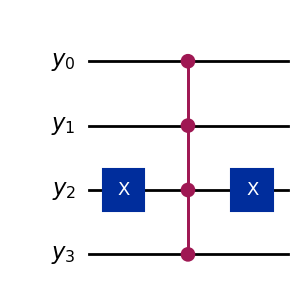

In [63]:
phase_circuit = QuantumCircuit(ancilla_register, name="phase circuit")

bin_expansion = bin(target_sum)[:1:-1]
t = bin_expansion + "0"*(bits_needed - len(bin_expansion))
print(t)

for i, bit in enumerate(t):
    if bit == '0':
        phase_circuit.x(ancilla_register[i])

mcz_gate_phase = ZGate().control(bits_needed-1)

phase_circuit.append(mcz_gate_phase, ancilla_register)

for i, bit in enumerate(t):
    if bit == '0':
        phase_circuit.x(ancilla_register[i])

Phase = phase_circuit.to_gate(label="phase")
phase_circuit.draw(output="mpl")

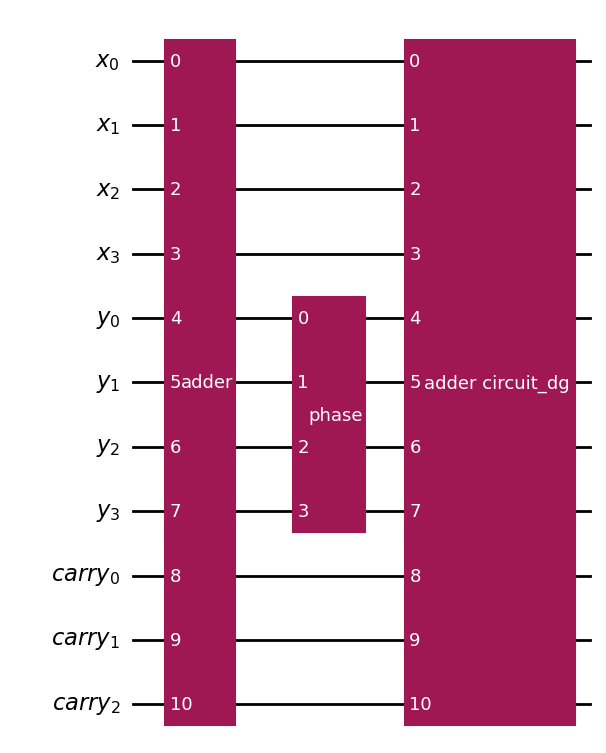

In [64]:
#k = n,  
#d = the number that's maximal bits_needed to represent the maximum possible sum of subsets of M.
# Adder = controlled_measurement_free_quantum_shifter(k,d)
# Adder.draw(output="mpl")
marker_circuit = QuantumCircuit(quantum_register, ancilla_register, carry_register)
marker_circuit.append(Adder, quantum_register[:] + ancilla_register[:] + carry_register[:])
marker_circuit.append(Phase, ancilla_register[:])
marker_circuit.append(Subtractor, quantum_register[:] + ancilla_register[:] + carry_register[:])
marker_circuit.draw(output="mpl")

In [65]:
Marker = marker_circuit.to_gate(label="marker")

## Diffuser Circuit


The diffuser oracle applied the $n$-qubit Hadamard operator, followed by a gate which implements a phase flip of $-1$ on all states but the all-zero state $\lvert 0 \rangle$. This gate acts only on the quantum register $|x\rangle$ representing a given subset.

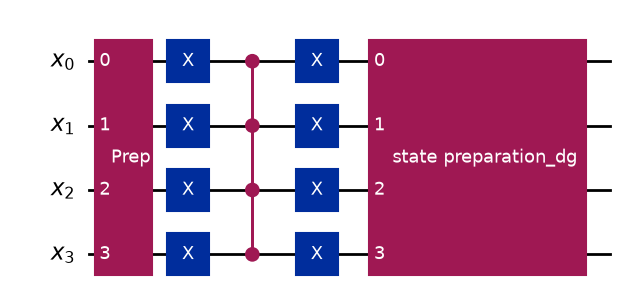

In [13]:
diffuser_circuit = QuantumCircuit(quantum_register, name="diffuser")

diffuser_circuit.compose(Prep, inplace=True)

diffuser_circuit.x(quantum_register)

mcz_gate = ZGate().control(n-1)

diffuser_circuit.append(mcz_gate, quantum_register)

diffuser_circuit.x(quantum_register)

diffuser_circuit.compose(Prep.inverse(), inplace=True)

Diffuser = diffuser_circuit.to_gate(label="diffuser")

diffuser_circuit.draw(output="mpl")

## Grover Iteration Operator

The Grover operator is defined as

$$
\text{Grover Iteration}
=
\text{Diffuser}
\circ
\text{Marker}.
$$

The marker oracle first applies a phase flip to the solution states, and the diffuser then amplifies their amplitudes through inversion about the mean.

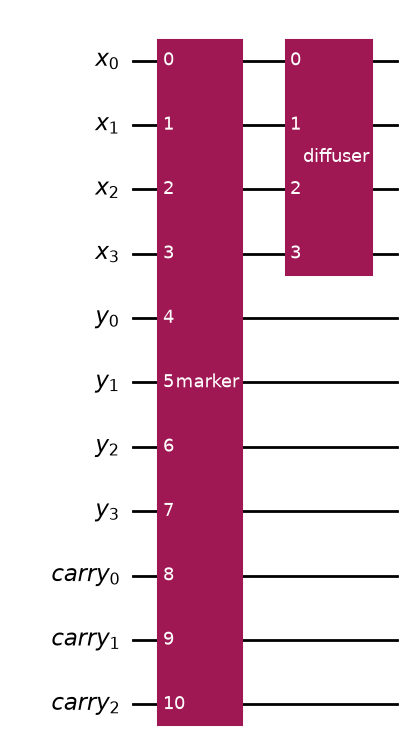

In [14]:
grover_circuit = QuantumCircuit(quantum_register, ancilla_register, carry_register, name="Grover iteration")
grover_circuit.append(Marker, quantum_register[:] + ancilla_register[:] + carry_register[:])
grover_circuit.append(Diffuser, quantum_register[:])

Grover = grover_circuit.to_gate(label="Grover iteration")

grover_circuit.draw(output="mpl")

## Full Grover Circuit

The Grover iteration operator is applied
$$
K = \frac{\pi}{4 \arcsin(1/\sqrt{N})} - \frac{1}{2}
$$
times in order to maximize the probability that the final state is close to the target state $\lvert t \rangle$.

3


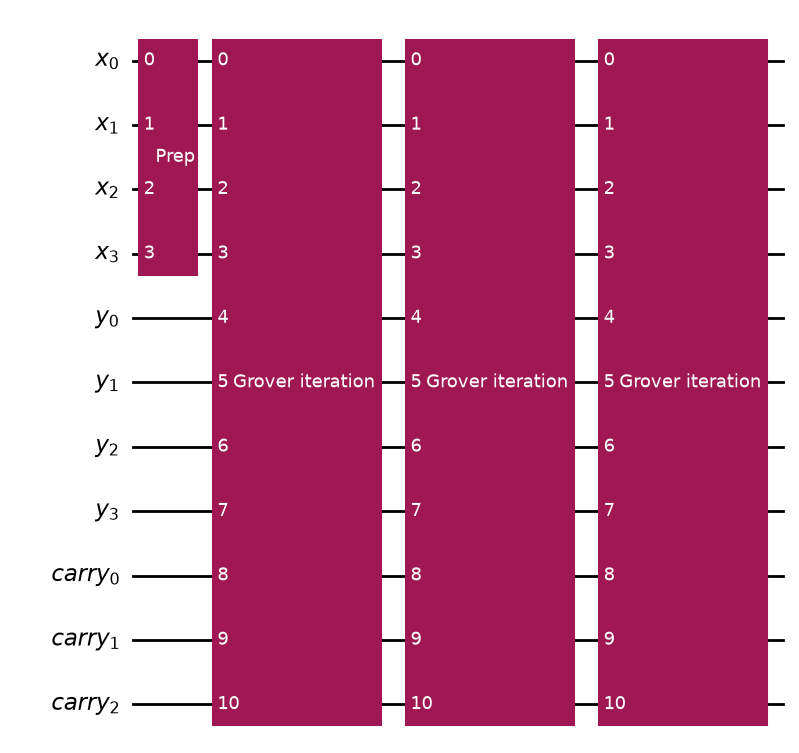

In [15]:
qc = QuantumCircuit(quantum_register, ancilla_register, carry_register)
qc.append(Prep, quantum_register)

N = 2**n
K = int(np.rint(np.pi / (4 * np.arcsin(1 / np.sqrt(N))) - 1/2))
print(K)

for _ in range(K):
    qc.append(Grover, quantum_register[:] + ancilla_register[:] + carry_register[:])

qc.draw(output="mpl")

# Result


Finally, we compute the probabilities for the subsystem consisting of the first $n$ qubits after the full Grover circuit is applied. The state with the maximum probability is the desired subset with high probability, if it exists.

In [16]:
psi = Statevector(qc)
psi.probabilities(qargs=range(n))
probabilities = np.round(psi.probabilities(qargs=range(n)), 2)

# The output probabilities show that the state |101> has the highest probability, which corresponds to the subset {1,4} that sums to 5.
# Extract the index of the highest probability state
most_probable_state_index = np.argmax(probabilities)
most_probable_state_binary = format(most_probable_state_index, f'0{n}b')[::-1]
print(f"Most probable state: |{most_probable_state_binary}>")

Most probable state: |1101>
